# Satellite Imagery Comparison
VHR / Sentinel-2 / Landsat at native resolution over the same geographic footprint.

In [2]:
pip install rasterio

   ---------------------------------------- 0.0/30.1 MB ? eta -:--:--
   - -------------------------------------- 0.8/30.1 MB 6.0 MB/s eta 0:00:05
   -- ------------------------------------- 1.8/30.1 MB 5.5 MB/s eta 0:00:06
   ---- ----------------------------------- 3.7/30.1 MB 6.6 MB/s eta 0:00:04
   ------- -------------------------------- 5.5/30.1 MB 7.4 MB/s eta 0:00:04
   ---------- ----------------------------- 7.9/30.1 MB 8.4 MB/s eta 0:00:03
   -------------- ------------------------- 10.7/30.1 MB 9.1 MB/s eta 0:00:03
   ----------------- ---------------------- 13.4/30.1 MB 9.6 MB/s eta 0:00:02
   -------------------- ------------------- 15.5/30.1 MB 9.6 MB/s eta 0:00:02
   ------------------------ --------------- 18.1/30.1 MB 10.0 MB/s eta 0:00:02
   -------------------------- ------------- 20.2/30.1 MB 10.1 MB/s eta 0:00:01
   ----------------------------- ---------- 22.0/30.1 MB 10.0 MB/s eta 0:00:01
   ------------------------------- -------- 23.6/30.1 MB 10.0 MB/s eta 0:0

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from rasterio.windows import from_bounds

VHR_PATH = "data/vhr/istanbul_vhr.tiff"

S2_PATHS = {
    "R": "data/stac_downloads/sentinel2/s2_B04.tif",
    "G": "data/stac_downloads/sentinel2/s2_B03.tif",
    "B": "data/stac_downloads/sentinel2/s2_B02.tif",
}

LS_PATHS = {
    "R": "data/stac_downloads/landsat/landsat_red.tif",
    "G": "data/stac_downloads/landsat/landsat_green.tif",
    "B": "data/stac_downloads/landsat/landsat_blue.tif",
}
S2_NIR_PATH = "data/stac_downloads/sentinel2/s2_B08.tif"
LS_NIR_PATH = "data/stac_downloads/landsat/landsat_nir08.tif"


In [4]:
def pstretch(arr, lo=2, hi=98):
    """2–98 % percentile stretch → [0, 1] float32."""
    a = arr.astype(np.float32)
    v = a[np.isfinite(a) & (a > 0)]
    if v.size == 0:
        return np.zeros_like(a)
    lo_v, hi_v = np.percentile(v, [lo, hi])
    return np.clip((a - lo_v) / (hi_v - lo_v + 1e-9), 0, 1)


def load_rgb(paths, bounds):
    """Read R/G/B single-band files windowed to bounds"""
    bands = []
    for key in ("R", "G", "B"):
        with rasterio.open(paths[key]) as src:
            win = from_bounds(*bounds, transform=src.transform)
            bands.append(src.read(1, window=win))
    return np.stack([pstretch(b) for b in bands], axis=-1)


def load_vhr_rgb(bounds):
    with rasterio.open(VHR_PATH) as src:
        win = from_bounds(*bounds, transform=src.transform)
        data = src.read([1, 2, 3], window=win)
    return np.stack([pstretch(data[i]) for i in range(3)], axis=-1)

## Full VHR footprint — three sensors side by side

In [5]:
# Use the VHR scene as the common bounding box
with rasterio.open(VHR_PATH) as src:
    vhr_bounds = src.bounds   # (left, bottom, right, top)

extent = [vhr_bounds.left, vhr_bounds.right, vhr_bounds.bottom, vhr_bounds.top]

vhr_rgb = load_vhr_rgb(vhr_bounds)
s2_rgb  = load_rgb(S2_PATHS, vhr_bounds)
ls_rgb  = load_rgb(LS_PATHS, vhr_bounds)

print(f"VHR  shape : {vhr_rgb.shape}   (~1 m/px)")
print(f"S2   shape : {s2_rgb.shape}  (~10 m/px)")
print(f"LS   shape : {ls_rgb.shape}   (~30 m/px)")

VHR  shape : (8742, 7841, 3)   (~1 m/px)
S2   shape : (874, 784, 3)  (~10 m/px)
LS   shape : (291, 261, 3)   (~30 m/px)


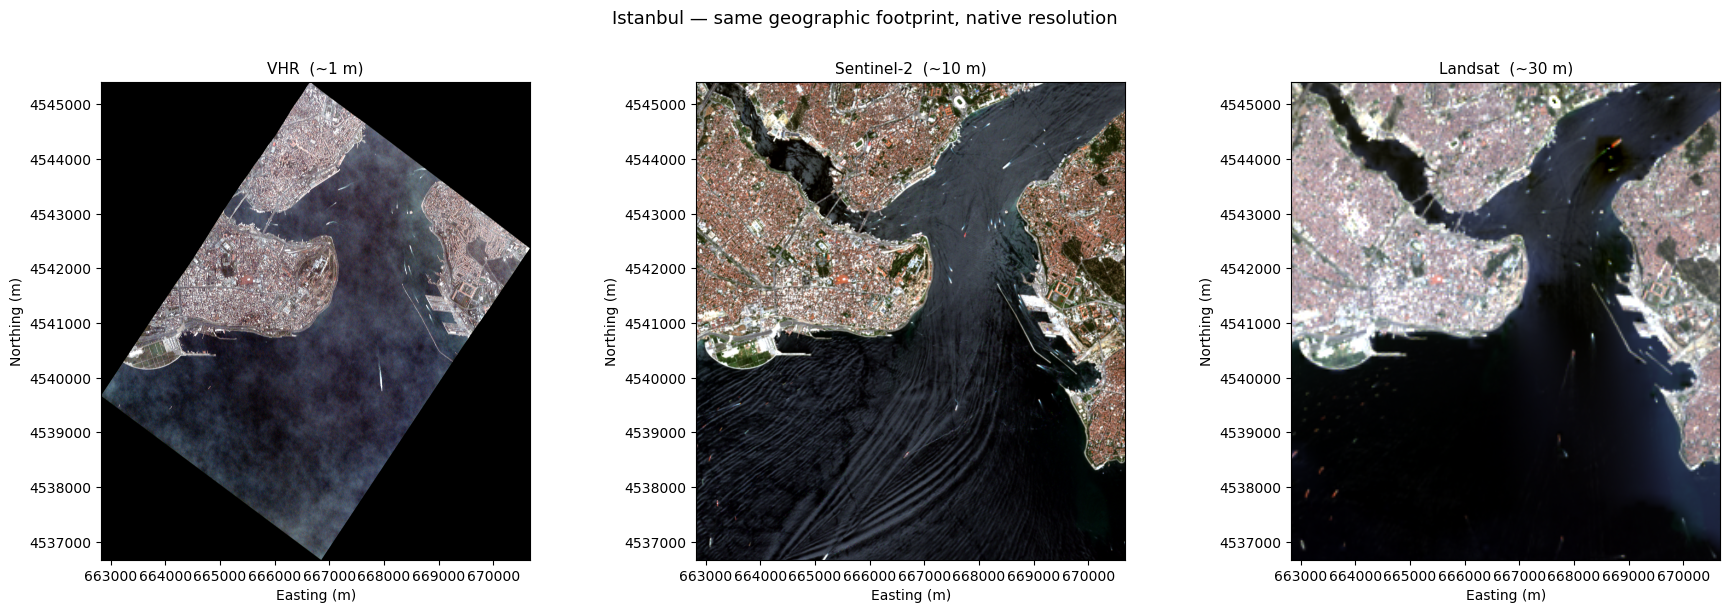

In [6]:
panels = [
    (vhr_rgb, "VHR  (~1 m)"),
    (s2_rgb,  "Sentinel-2  (~10 m)"),
    (ls_rgb,  "Landsat  (~30 m)"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6),
                         subplot_kw={"aspect": "equal"})
fig.suptitle("Istanbul — same geographic footprint, native resolution",
             fontsize=13, y=1.01)

for ax, (img, title) in zip(axes, panels):
    ax.imshow(img, extent=extent, origin="upper", interpolation="bilinear")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    ax.ticklabel_format(style="plain")

plt.tight_layout()
plt.show()

## Zoom — 2 km × 2 km patch (centre of VHR scene)

In [7]:
# Pick a 2 km × 2 km window from the centre of the VHR scene
cx = (vhr_bounds.left + vhr_bounds.right)  / 2
cy = (vhr_bounds.bottom + vhr_bounds.top)  / 2
half = 1000   # metres

from rasterio.coords import BoundingBox
zoom_bounds = BoundingBox(cx - half, cy - half, cx + half, cy + half)
zoom_extent = [zoom_bounds.left, zoom_bounds.right,
               zoom_bounds.bottom, zoom_bounds.top]

vhr_z = load_vhr_rgb(zoom_bounds)
s2_z  = load_rgb(S2_PATHS, zoom_bounds)
ls_z  = load_rgb(LS_PATHS, zoom_bounds)

print(f"VHR  zoom : {vhr_z.shape}")
print(f"S2   zoom : {s2_z.shape}")
print(f"LS   zoom : {ls_z.shape}")

VHR  zoom : (2000, 2000, 3)
S2   zoom : (200, 200, 3)
LS   zoom : (67, 67, 3)


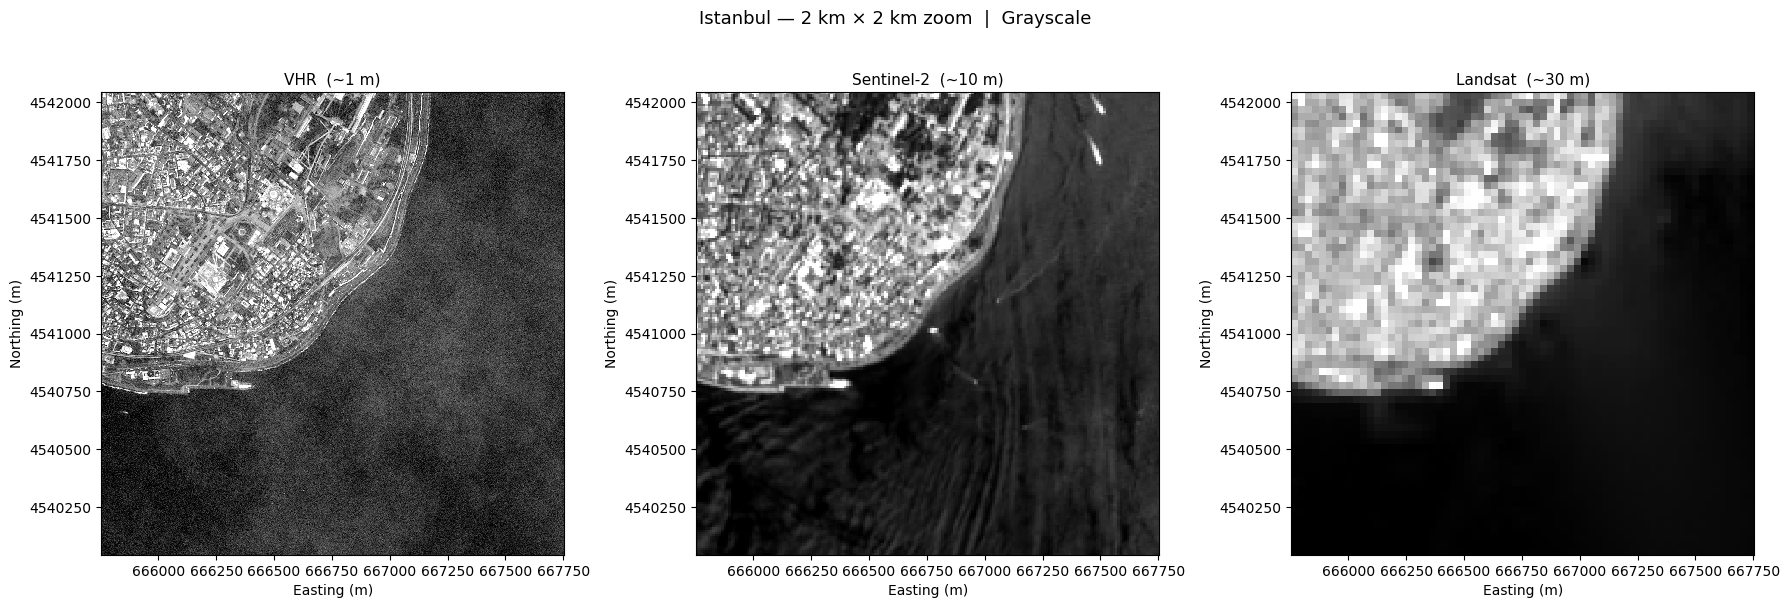

In [8]:
# Grayscale — luminance of each zoom RGB
def to_grey(rgb):
    """ITU-R BT.601 luminance."""
    return 0.299 * rgb[..., 0] + 0.587 * rgb[..., 1] + 0.114 * rgb[..., 2]

grey_panels = [
    (to_grey(vhr_z), "VHR  (~1 m)"),
    (to_grey(s2_z),  "Sentinel-2  (~10 m)"),
    (to_grey(ls_z),  "Landsat  (~30 m)"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6),
                          subplot_kw={"aspect": "equal"})
fig.suptitle("Istanbul — 2 km × 2 km zoom  |  Grayscale",
             fontsize=13, y=1.01)

for ax, (img, title) in zip(axes, grey_panels):
    ax.imshow(img, extent=zoom_extent, origin="upper",
              cmap="gray", interpolation="none")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    ax.ticklabel_format(style="plain")

plt.tight_layout()
plt.show()


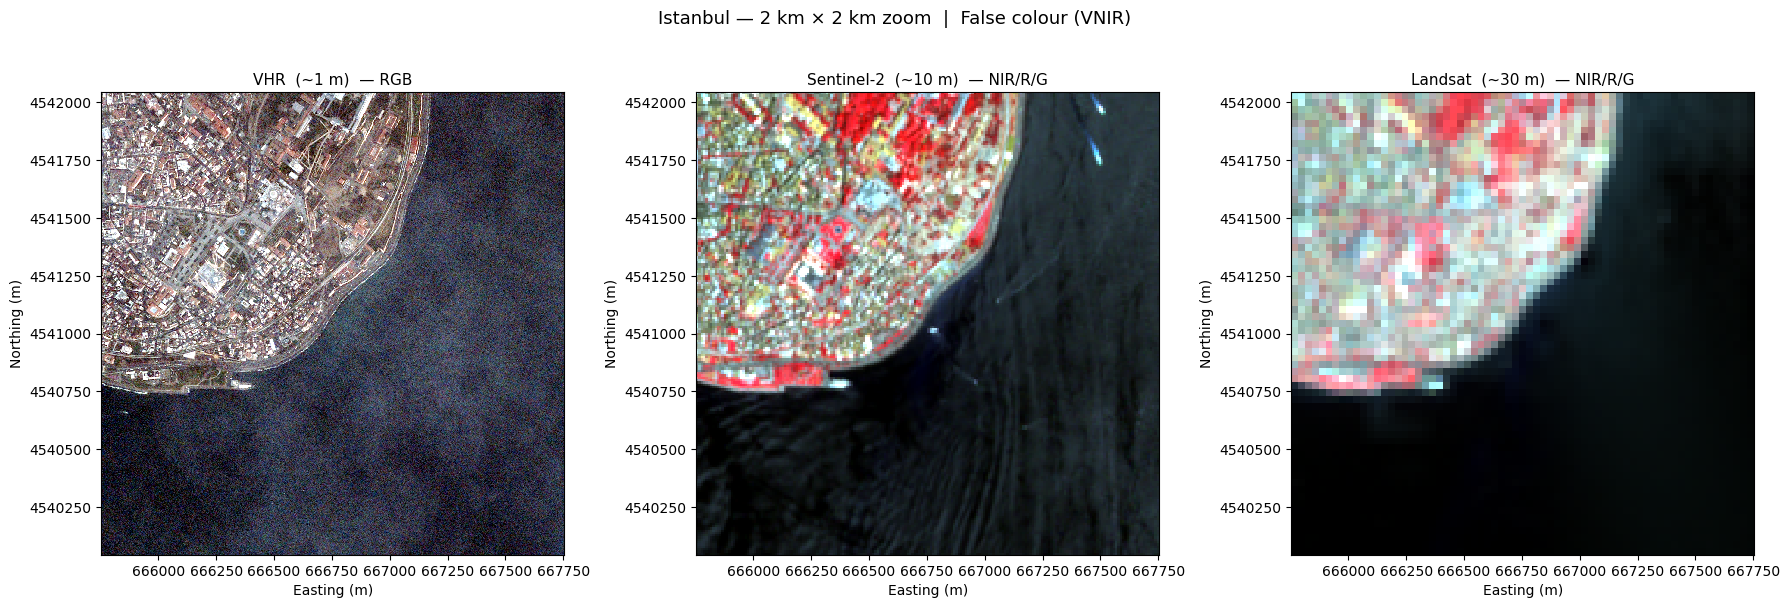

In [10]:
# False colour — NIR/R/G for S2 & Landsat; RGB for VHR (no NIR available)
def load_single(path, bounds):
    with rasterio.open(path) as src:
        win = from_bounds(*bounds, transform=src.transform)
        return src.read(1, window=win)

# S2: NIR(B08) – Red(B04) – Green(B03)
s2_fc = np.stack([
    pstretch(load_single(S2_NIR_PATH, zoom_bounds)),
    pstretch(load_single(S2_PATHS["R"], zoom_bounds)),
    pstretch(load_single(S2_PATHS["G"], zoom_bounds)),
], axis=-1)

# Landsat: NIR – Red – Green
ls_fc = np.stack([
    pstretch(load_single(LS_NIR_PATH, zoom_bounds)),
    pstretch(load_single(LS_PATHS["R"], zoom_bounds)),
    pstretch(load_single(LS_PATHS["G"], zoom_bounds)),
], axis=-1)

fc_panels = [
    (vhr_z,  "VHR  (~1 m)  — RGB"),
    (s2_fc,  "Sentinel-2  (~10 m)  — NIR/R/G"),
    (ls_fc,  "Landsat  (~30 m)  — NIR/R/G"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6),
                          subplot_kw={"aspect": "equal"})
fig.suptitle("Istanbul — 2 km × 2 km zoom  |  False colour (VNIR)",
             fontsize=13, y=1.01)

for ax, (img, title) in zip(axes, fc_panels):
    ax.imshow(img, extent=zoom_extent, origin="upper", interpolation="none")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    ax.ticklabel_format(style="plain")

plt.tight_layout()
plt.show()


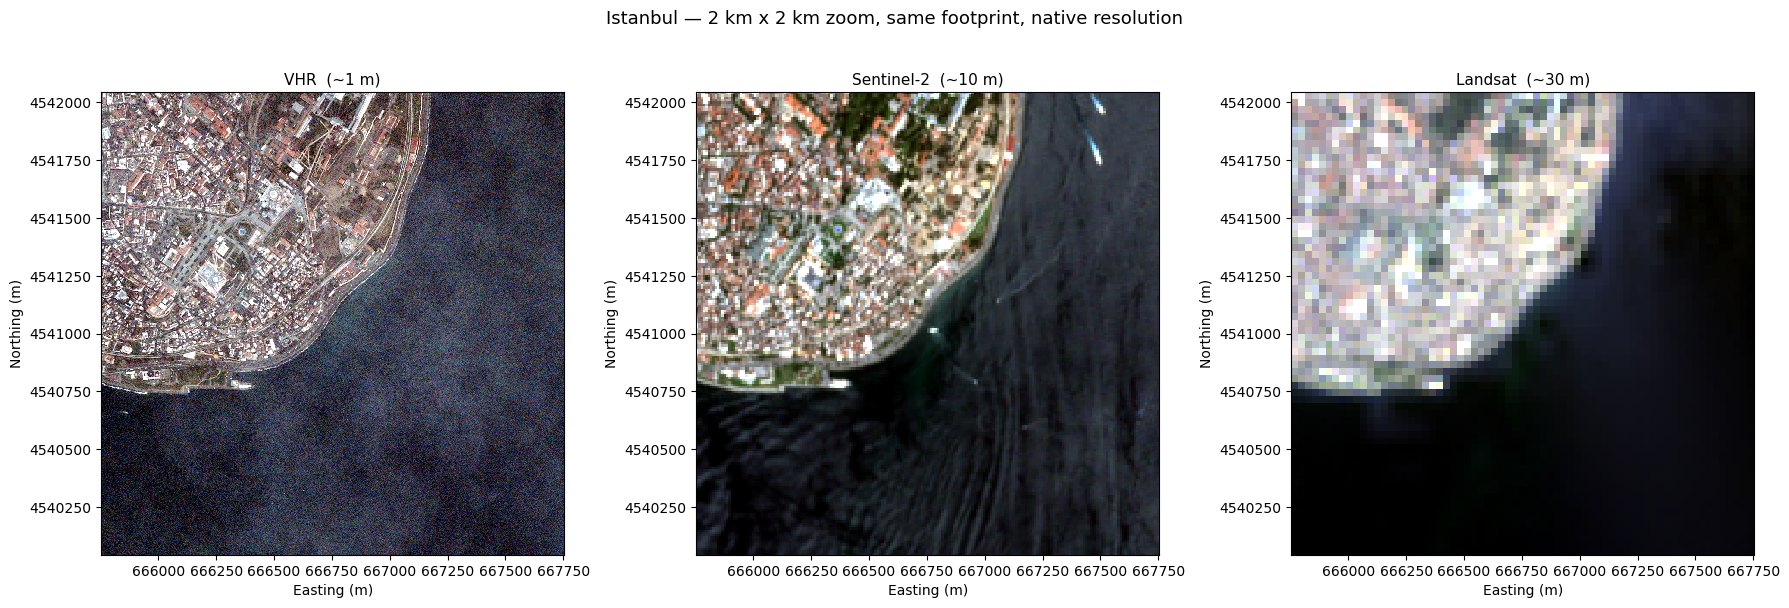

In [11]:
zoom_panels = [
    (vhr_z, "VHR  (~1 m)"),
    (s2_z,  "Sentinel-2  (~10 m)"),
    (ls_z,  "Landsat  (~30 m)"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6),
                         subplot_kw={"aspect": "equal"})
fig.suptitle("Istanbul — 2 km x 2 km zoom, same footprint, native resolution",
             fontsize=13, y=1.01)

for ax, (img, title) in zip(axes, zoom_panels):
    ax.imshow(img, extent=zoom_extent, origin="upper", interpolation="none")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    ax.ticklabel_format(style="plain")

plt.tight_layout()
plt.show()

Shared NDVI colour scale: -0.025 – 0.383


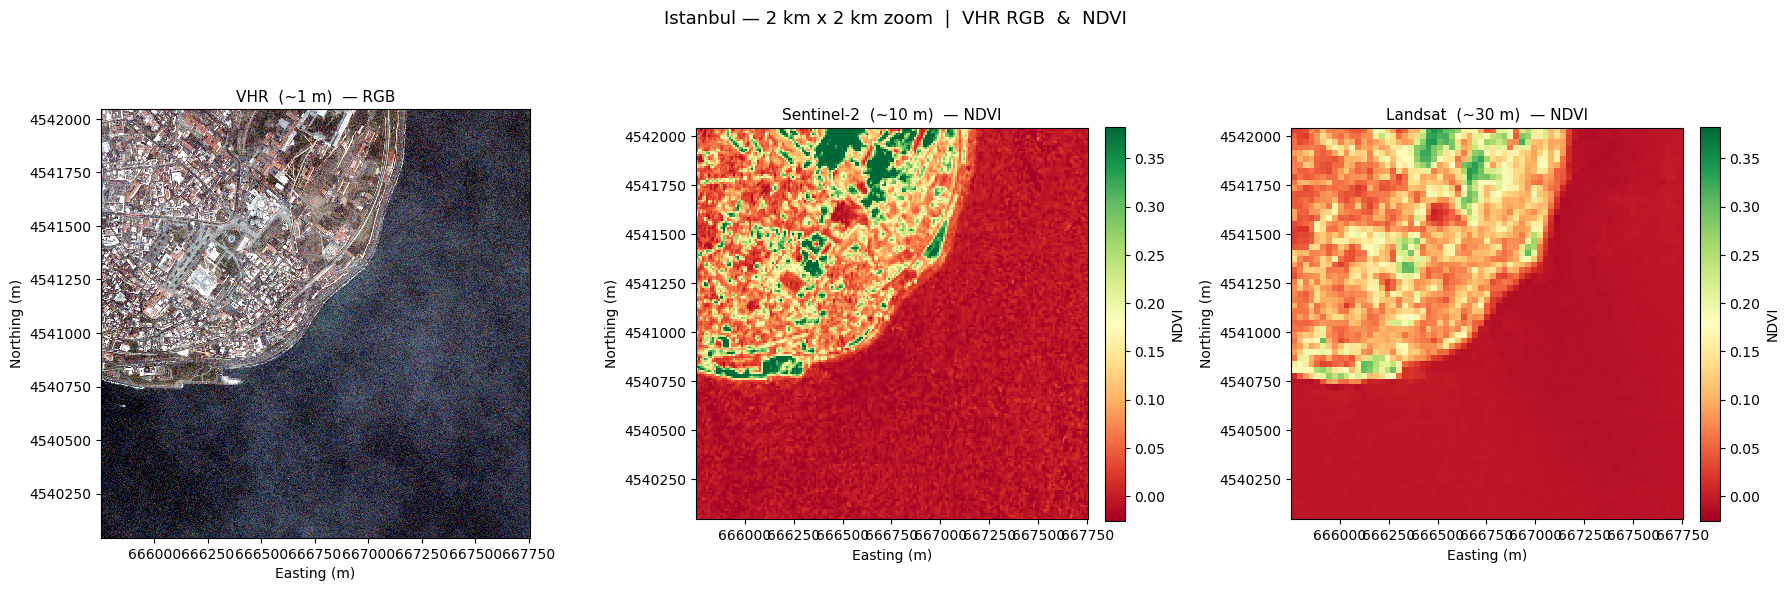

In [12]:
# NDVI = (NIR - Red) / (NIR + Red)
def ndvi(nir_path, red_path, bounds):
    nir = load_single(nir_path, bounds).astype(np.float32)
    red = load_single(red_path, bounds).astype(np.float32)
    with np.errstate(invalid="ignore", divide="ignore"):
        idx = np.where((nir + red) > 0, (nir - red) / (nir + red), np.nan)
    return idx

s2_ndvi = ndvi(S2_NIR_PATH, S2_PATHS["R"], zoom_bounds)
ls_ndvi = ndvi(LS_NIR_PATH, LS_PATHS["R"], zoom_bounds)

# Shared colour scale derived from actual data (2–98 % percentile)
combined = np.concatenate([
    s2_ndvi[np.isfinite(s2_ndvi)],
    ls_ndvi[np.isfinite(ls_ndvi)],
])
vmin, vmax = np.percentile(combined, [2, 98])
print(f"Shared NDVI colour scale: {vmin:.3f} – {vmax:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 6),
                          subplot_kw={"aspect": "equal"})
fig.suptitle("Istanbul — 2 km x 2 km zoom  |  VHR RGB  &  NDVI",
             fontsize=13, y=1.01)

# VHR true colour
axes[0].imshow(vhr_z, extent=zoom_extent, origin="upper", interpolation="none")
axes[0].set_title("VHR  (~1 m)  — RGB", fontsize=11)

# S2 NDVI
im1 = axes[1].imshow(s2_ndvi, extent=zoom_extent, origin="upper",
                      interpolation="none", cmap="RdYlGn", vmin=vmin, vmax=vmax)
axes[1].set_title("Sentinel-2  (~10 m)  — NDVI", fontsize=11)
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04, label="NDVI")

# Landsat NDVI
im2 = axes[2].imshow(ls_ndvi, extent=zoom_extent, origin="upper",
                      interpolation="none", cmap="RdYlGn", vmin=vmin, vmax=vmax)
axes[2].set_title("Landsat  (~30 m)  — NDVI", fontsize=11)
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04, label="NDVI")

for ax in axes:
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    ax.ticklabel_format(style="plain")

plt.tight_layout()
plt.show()
